# First sample histograms

Load a GUNDAM engine and compare the model/data histogram contents for the first sample.

In [7]:
nCpuThreads = 3
gundamLibPath = "/Users/nadrino/Documents/Work/Install/gundam/lib"
workDir = "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024"
configPath = "configOA2024.yaml"
overrideList = [
    "override/v12ProdRun45.yaml",
    "override/onlyFlux5.yaml",
    "override/noEigen.yaml",
]
dataType = "Toy"  # "Asimov", "Toy", or "RealData"
seed = 12345

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repoRoot = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
srcPath = repoRoot / "src"
if srcPath.exists() and str(srcPath) not in sys.path:
    sys.path.insert(0, str(srcPath))

from gundam_interface import GundamInterface, GundamLoader, GundamRuntime

In [9]:
np.random.seed(seed)

runtime = GundamRuntime(
    loader=GundamLoader(gundamLibPath=gundamLibPath),
    workDir=workDir,
    nCpuThreads=nCpuThreads,
    configPath=configPath,
    overrideList=overrideList,
    dataType=dataType,
    randomSeed=seed,
)

runtime.toDict(includeConfigJsonString=False)

{'nCpuThreads': 3,
 'workDir': '/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024',
 'dataType': 'Toy',
 'loader': {'moduleName': 'GUNDAM',
  'gundamLibPath': '/Users/nadrino/Documents/Work/Install/gundam/lib'},
 'randomSeed': 12345,
 'configPath': 'configOA2024.yaml',
 'overrideList': ['override/v12ProdRun45.yaml',
  'override/onlyFlux5.yaml',
  'override/noEigen.yaml']}

In [10]:
gundam = GundamInterface(runtime)
gundam.configure()
gundam.initialize()

2026.06.30 16:46:32  INFO ConfigUtils: Reading config file: /Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/configOA2024.yaml
2026.06.30 16:46:32  INFO ConfigUtils: Overriding config with "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/override/v12ProdRun45.yaml"
2026.06.30 16:46:32  WARN ConfigUtils:   Added: fitterEngineConfig/propagatorConfig/dataSetList/0(name:"ND280")/mc/filePathList
2026.06.30 16:46:32  WARN ConfigUtils:   Added: fitterEngineConfig/propagatorConfig/dataSetList/0(name:"ND280")/data/0(name:"data")/filePathList
2026.06.30 16:46:32  INFO ConfigUtils: Overriding config with "/Users/nadrino/Documents/Work/Output/results/gundam/GundamInputOA2024/override/onlyFlux5.yaml"
2026.06.30 16:46:32  WARN ConfigUtils:   Override: fitterEngineConfig/propagatorConfig/parameterSetListConfig/0(name:"Flux Systematics")/isEnabled: true -> false
2026.06.30 16:46:32  WARN ConfigUtils:   Override: fitterEngineConfig/propagatorConfig/parameterSe

In [11]:
sampleIndex = 0

modelSample = gundam.modelSamples[sampleIndex]
dataSample = gundam.dataSamples[sampleIndex]

sampleName = modelSample.handle.getName()
modelSumWeights = modelSample.sumWeights
dataSumWeights = dataSample.sumWeights

print(f"Model bins: {modelSumWeights.shape[0]}")
print(f"Data bins:  {dataSumWeights.shape[0]}")

Model bins: 252
Data bins:  252


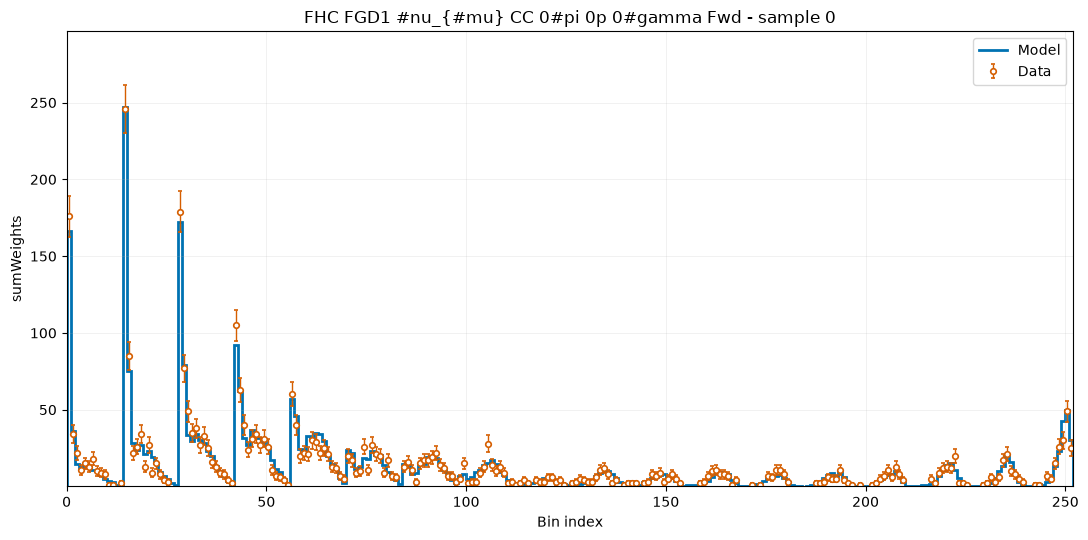

In [14]:
nBins = max(modelSumWeights.shape[0], dataSumWeights.shape[0])
binEdges = np.arange(nBins + 1)
binCenters = binEdges[:-1] + 0.5

modelPositive = np.pad(modelSumWeights > 0, (0, nBins - modelSumWeights.shape[0]))
dataPositive = np.pad(dataSumWeights > 0, (0, nBins - dataSumWeights.shape[0]))
nonEmptyBins = np.flatnonzero(modelPositive | dataPositive)
dataMask = dataSumWeights > 0

fig, ax = plt.subplots(figsize=(11, 5.5))

modelColor = "#0072B2"
dataColor = "#D55E00"

ax.stairs(
    modelSumWeights,
    binEdges[: modelSumWeights.shape[0] + 1],
    label="Model",
    color=modelColor,
    linewidth=2.0,
)
ax.errorbar(
    binCenters[: dataSumWeights.shape[0]][dataMask],
    dataSumWeights[dataMask],
    yerr=np.sqrt(dataSumWeights[dataMask]),
    fmt="o",
    color=dataColor,
    markerfacecolor="white",
    markeredgewidth=1.2,
    elinewidth=1.0,
    capsize=1.5,
    markersize=4,
    label="Data",
)

if nonEmptyBins.size:
    ax.set_xlim(max(0, nonEmptyBins.min() - 1), min(nBins, nonEmptyBins.max() + 2))

positiveValues = np.concatenate([
    modelSumWeights[modelSumWeights > 0],
    dataSumWeights[dataSumWeights > 0],
])
if positiveValues.size:
    ax.set_ylim(positiveValues.min() * 0.1, positiveValues.max() * 1.2)

# ax.set_yscale("log")
ax.set_xlabel("Bin index")
ax.set_ylabel("sumWeights")
ax.set_title(f"{sampleName} - sample {sampleIndex}")
ax.grid(alpha=0.25, which="both")
ax.legend()
fig.tight_layout()